<a href="https://colab.research.google.com/github/islombek-cs/Computer-Vision-Labs/blob/main/Lab01_Intro_Digital_Image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 1 — Introduction & The Digital Image (Colab)

**Course:** 4-COV-10-413 · Computer Vision  
**Duration:** ~90 minutes  
**Environment:** Google Colab (no local install needed)

## Learning Objectives
- Understand digital image representation (pixels, channels, color spaces).
- Load, display, and manipulate images in Python.
- Practice basic transformations: grayscale conversion, histograms, channel ops.
- Get ready for next week (filtering & edges) with a short noise/denoise exploration.

> **Submission**: Keep this notebook complete and runnable. Add your reflections at the end.


In [1]:

# === Setup (Colab) ===
# If you reconnect your Colab runtime, re-run this cell.

#!pip -q install opencv-python-headless scikit-image

print("Setup complete. Versions:")
import sys, numpy, cv2, skimage, matplotlib
print("Python:", sys.version.split()[0])
print("NumPy:", numpy.__version__)
print("OpenCV:", cv2.__version__)
print("scikit-image:", skimage.__version__)
print("Matplotlib:", matplotlib.__version__)


Setup complete. Versions:
Python: 3.12.12
NumPy: 2.0.2
OpenCV: 4.12.0
scikit-image: 0.25.2
Matplotlib: 3.10.0


In [2]:

# === Imports & Utilities ===
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data, io, color, img_as_float
from google.colab import files

# Display helpers (RGB handling for OpenCV images)
def imshow(img, title=None, cmap=None, isOpencv=False):
    plt.figure(figsize=(5,5))
    if img.ndim == 3 and img.shape[2] == 3:
        # If it's BGR (OpenCV), convert to RGB for proper display
        # Heuristic: when loaded by cv2, it's BGR; when from skimage, it's already RGB
        # We'll assume: if dtype is uint8 and any OpenCV ops used, convert BGR->RGB
        # Safer: provide a toggle parameter (skimage already returns RGB)
        try:
            # Try detecting if likely BGR: check if red/blue channel means are swapped

            if isOpencv:  # rough heuristic for natural images
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        except Exception:
            pass
    if cmap:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

def show_side_by_side(images, titles=None, cmaps=None, figsize=(12,4), isOpencv=[]):
    n = len(images)
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(1, n, i+1)
        cmap = None if cmaps is None else cmaps[i]
        if img.ndim == 3 and img.shape[2] == 3:
            try:
                if isOpencv!= None and len(isOpencv)==n and isOpencv[i]:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            except Exception:
                pass
        plt.imshow(img, cmap=cmap)
        if titles:
            plt.title(titles[i])
        plt.axis('off')
    plt.show()


**bold text**
## Part 0 — Data
You can use **built-in sample images** from `skimage.data` or **upload your own** photo (recommended for engagement).


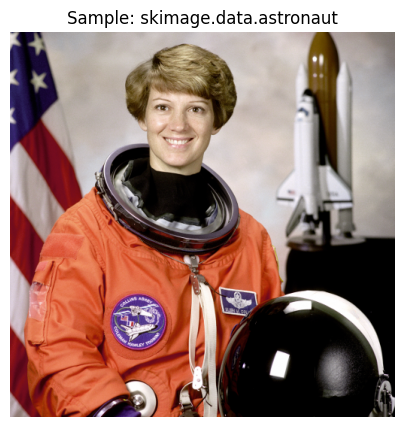

Saving prod img 2 - wintersale.jpg to prod img 2 - wintersale.jpg


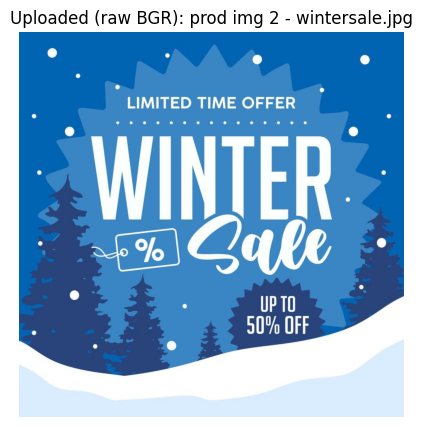

Uploaded files: ['prod img 2 - wintersale.jpg']


In [4]:

# Built-in sample images (feel free to try others from skimage.data)
img_skimage = img_as_float(data.astronaut())   # RGB image
imshow(img_skimage, "Sample: skimage.data.astronaut")

# Optional: upload your own image(s)
# After you run this cell, select an image file from your computer.
uploaded = files.upload()
user_imgs = {}
for name, content in uploaded.items():
    # Read via OpenCV (BGR uint8) to practice conversions
    file_bytes = np.frombuffer(content, np.uint8)
    img_cv = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)  # BGR
    user_imgs[name] = img_cv
    imshow(img_cv, f"Uploaded (raw BGR): {name}", isOpencv=True)
print(f"Uploaded files: {list(user_imgs.keys())}")



---
## Part A — Image Basics
**Goal:** Understand shapes, dtypes, and grayscale conversion. Visualize histograms.


Shape (H, W, C): (512, 512, 3) | dtype: uint8


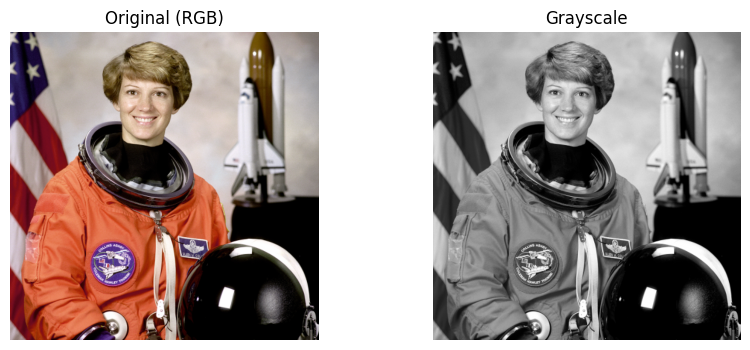

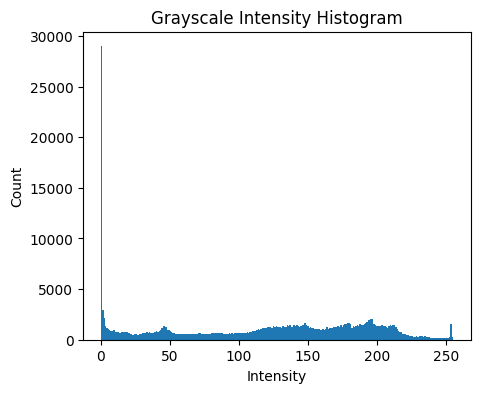

In [5]:

# Use built-in image for determinism; you can also pick one uploaded image
img = (img_skimage * 255).astype(np.uint8)  # make uint8 for easier OpenCV ops
print("Shape (H, W, C):", img.shape, "| dtype:", img.dtype)

# Convert to grayscale (OpenCV expects BGR)
img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

show_side_by_side(
    [img, img_gray],
    titles=["Original (RGB)", "Grayscale"],
    cmaps=[None, "gray"],
    figsize=(10,4)
)

# Histogram of grayscale
plt.figure(figsize=(5,4))
plt.hist(img_gray.ravel(), bins=256, range=(0,255))
plt.title("Grayscale Intensity Histogram")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.show()


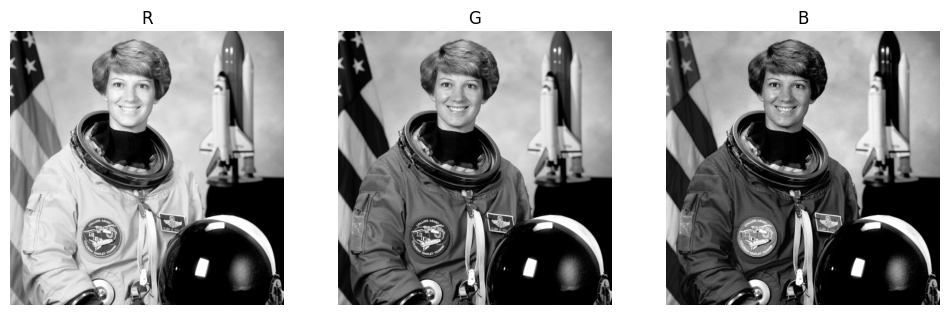

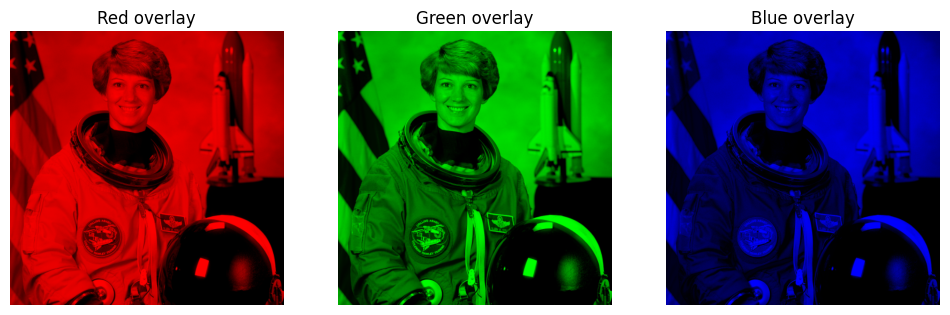

In [6]:

# Channel separation (from RGB)
R = img[...,0]
G = img[...,1]
B = img[...,2]

show_side_by_side([R, G, B], titles=["R", "G", "B"], cmaps=["gray","gray","gray"], figsize=(12,4))

# Visualize channels as color overlays (for intuition)
zeros = np.zeros_like(R)
red_vis   = np.stack([R, zeros, zeros], axis=2)
green_vis = np.stack([zeros, G, zeros], axis=2)
blue_vis  = np.stack([zeros, zeros, B], axis=2)
show_side_by_side([red_vis, green_vis, blue_vis], titles=["Red overlay","Green overlay","Blue overlay"], figsize=(12,4))


Reflection – Part A (Image Basics)
The original color image has a shape of (512, 512, 3) and dtype uint8, meaning it contains three color channels (RGB) with pixel values from 0 to 255.
Converting it to grayscale reduces it to a single intensity channel (512 × 512). The grayscale histogram shows a wide spread across intensities, indicating balanced contrast with both dark and bright regions.
Separating the RGB channels reveals that the red channel is the brightest because the astronaut’s suit is orange-red, while the blue channel contributes least. Visualizing overlays demonstrates how each channel combines to produce the full-color image.


---
## Part B — Color Spaces (RGB ↔ HSV, LAB)
**Goal:** See how images look in different color spaces and why that matters.


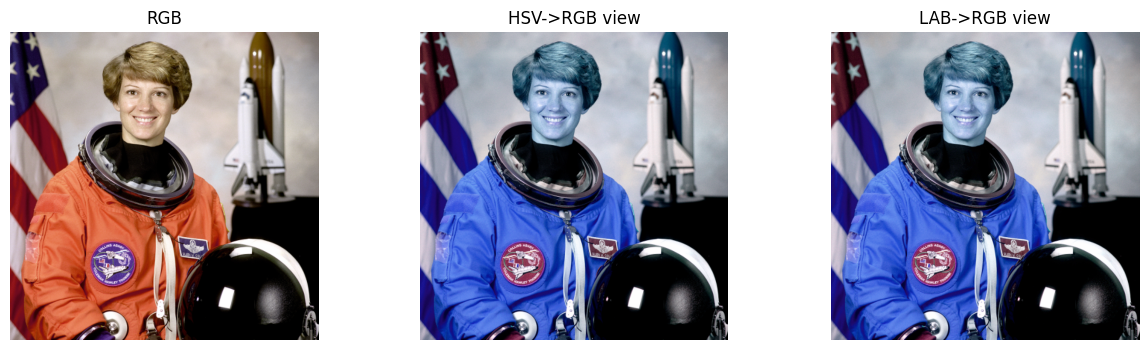

HSV-H: dtype=uint8, min=0, max=179, mean=38.65, std=59.32
HSV-S: dtype=uint8, min=0, max=255, mean=90.98, std=88.10
HSV-V: dtype=uint8, min=0, max=255, mean=142.92, std=81.27
LAB-L: dtype=uint8, min=0, max=255, mean=121.70, std=76.71
LAB-a: dtype=uint8, min=114, max=190, mean=141.58, std=17.67
LAB-b: dtype=uint8, min=76, max=190, mean=139.96, std=18.34


In [7]:

# Convert RGB to other spaces via OpenCV (expects BGR input)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)   # H in [0,179], S,V in [0,255] (OpenCV ranges)
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)   # L in [0,255], a,b ~ [0,255]

# For visualization, convert back to RGB just for display
hsv_to_rgb = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2BGR)
lab_to_rgb = cv2.cvtColor(img_lab, cv2.COLOR_LAB2BGR)

show_side_by_side([img, hsv_to_rgb, lab_to_rgb], titles=["RGB", "HSV->RGB view", "LAB->RGB view"], figsize=(15,4), isOpencv=True)

# Inspect channel ranges/statistics
def stats(arr, name):
    print(f"{name}: dtype={arr.dtype}, min={arr.min()}, max={arr.max()}, mean={arr.mean():.2f}, std={arr.std():.2f}")

stats(img_hsv[...,0], "HSV-H")
stats(img_hsv[...,1], "HSV-S")
stats(img_hsv[...,2], "HSV-V")
stats(img_lab[...,0], "LAB-L")
stats(img_lab[...,1], "LAB-a")
stats(img_lab[...,2], "LAB-b")


Reflection – Part B (Color Spaces)
The original image is in RGB, where each channel directly stores red, green, and blue intensities. Converting to HSV separates color into hue (H), saturation (S), and value/brightness (V). From the printed stats, H lies in the range [0, 179], while S and V are in [0, 255]. This matches OpenCV’s convention for HSV.
In LAB space, the L channel represents lightness and the a/b channels represent color-opponent components (green–red and blue–yellow). The L values also range roughly [0, 255], while a and b cluster around mid-range values, showing that the image colors are not extremely saturated at the extremes.
Visually, converting to HSV→RGB and LAB→RGB gives images that look very similar to the original RGB, but these color spaces are more convenient for some tasks: HSV is useful when we want to change or threshold only the hue or brightness, and LAB is useful when we want a representation that is closer to human perception and separates lightness from color.


---
## Part C — Simple Transformations
**Goal:** Resize, crop, brightness/contrast adjustments.


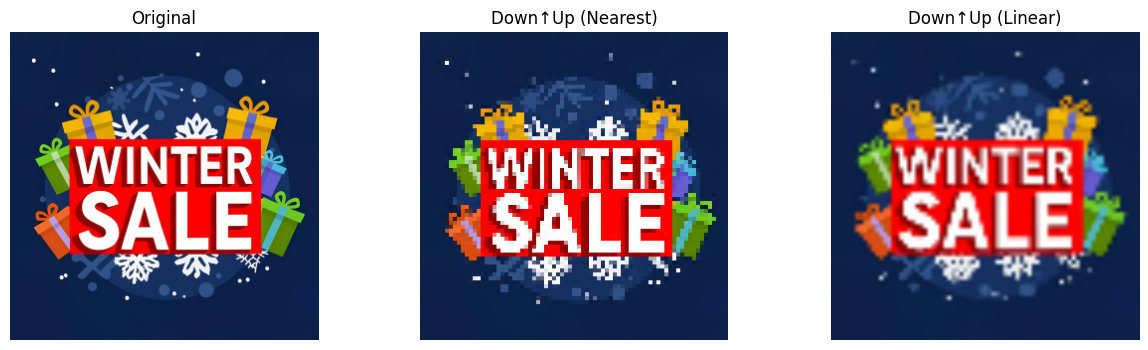

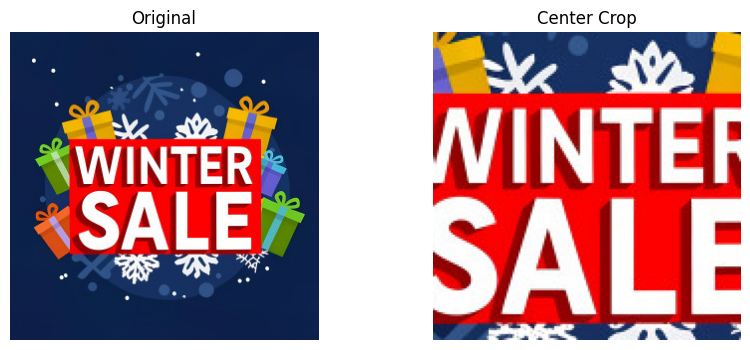

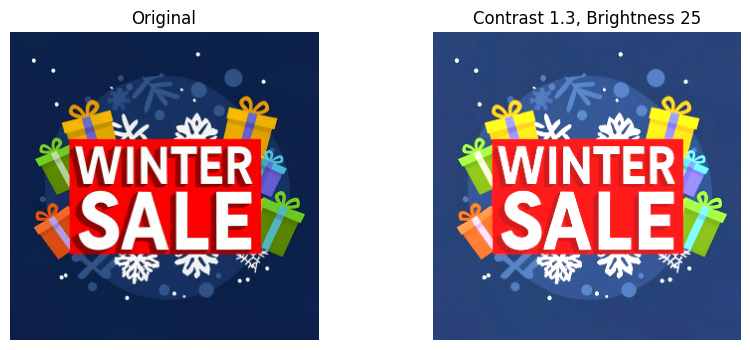

In [15]:

# Resize (downsample and upsample) with different interpolations
down_nn  = cv2.resize(img, (img.shape[1]//4, img.shape[0]//4), interpolation=cv2.INTER_NEAREST)
down_lin = cv2.resize(img, (img.shape[1]//4, img.shape[0]//4), interpolation=cv2.INTER_LINEAR)
up_nn    = cv2.resize(down_nn, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
up_lin   = cv2.resize(down_lin, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_LINEAR)

show_side_by_side([img, up_nn, up_lin], titles=["Original", "Down↑Up (Nearest)", "Down↑Up (Linear)"], figsize=(15,4))

# Crop ROI (center crop 50%)
h, w = img.shape[:2]
ch, cw = h//2, w//2
roi = img[h//4: h//4+ch, w//4: w//4+cw]
show_side_by_side([img, roi], titles=["Original", "Center Crop"], figsize=(10,4))

# Brightness/Contrast using OpenCV scale (alpha for contrast, beta for brightness)
alpha = 1.3  # contrast (>1 increases contrast)
beta  = 25   # brightness (additive)
img_bc = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
show_side_by_side([img, img_bc], titles=["Original", f"Contrast {alpha}, Brightness {beta}"], figsize=(10,4))



---
## Part D — Mini-Exploration (Noise → Blur)
**Goal:** Add Gaussian noise, then try a blur filter to see its effect.  
This preps you for next week (Filtering & Edges).


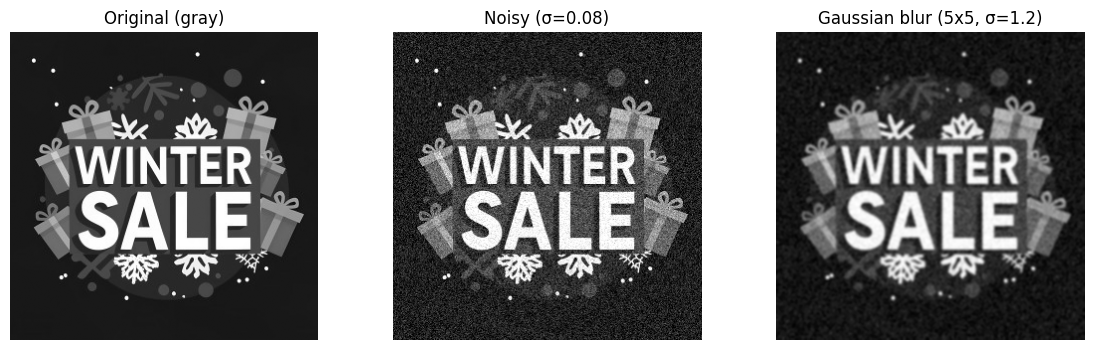

In [16]:

# Add Gaussian noise to a grayscale image, then denoise with Gaussian blur
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
np.random.seed(0)
noise = np.random.normal(0, 0.08, size=gray.shape).astype(np.float32)
noisy = np.clip(gray + noise, 0, 1)

# Denoise with Gaussian blur
noisy_uint8 = (noisy * 255).astype(np.uint8)
denoised = cv2.GaussianBlur(noisy_uint8, (5,5), sigmaX=1.2)

show_side_by_side([gray, noisy, denoised],
                  titles=["Original (gray)", "Noisy (σ=0.08)", "Gaussian blur (5x5, σ=1.2)"],
                  cmaps=["gray","gray","gray"],
                  figsize=(14,4))



### (Optional) Challenge
1. Try `medianBlur` instead of `GaussianBlur`. On which images (or noise types) does it work better?
2. Try `bilateralFilter`. What trade-offs do you observe compared to Gaussian blur?
3. If you uploaded your own image, repeat Part C/D with it.


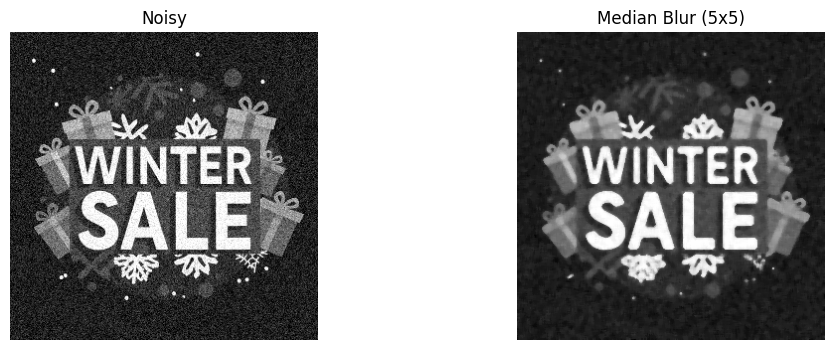

In [17]:
median = cv2.medianBlur(noisy_uint8, 5)
show_side_by_side([noisy_uint8, median], titles=["Noisy", "Median Blur (5x5)"], cmaps=["gray", "gray"])

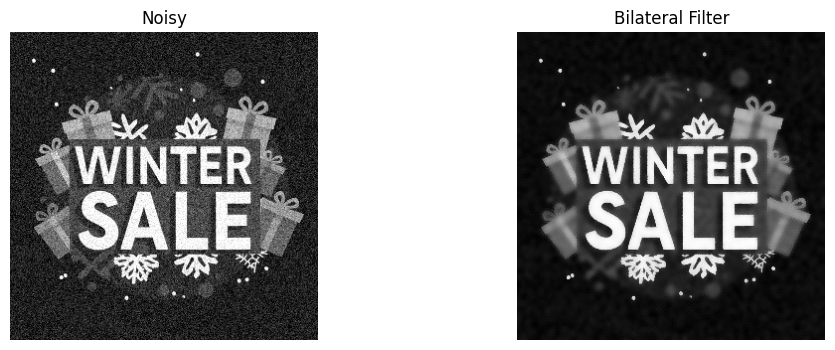

In [18]:
bilateral = cv2.bilateralFilter(noisy_uint8, 9, 75, 75)
show_side_by_side([noisy_uint8, bilateral], titles=["Noisy", "Bilateral Filter"], cmaps=["gray", "gray"])

In [13]:
from google.colab import files
uploaded = files.upload()


Saving prod img 1 - winter.jpg to prod img 1 - winter (1).jpg


In [14]:
import cv2
img = cv2.imread("prod img 1 - winter.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


---
## Reflection (Short Paragraph)
In 5–8 sentences, reflect on what you learned about how computers represent and manipulate images.
- Which color space representation surprised you, and why?
- What did the histogram reveal about your image?
- How did different interpolation methods affect quality?

In this lab, I learned how computers represent images as pixel matrices with numerical values for each color channel. The LAB color space surprised me because it separates lightness from color, making it easier to adjust brightness without affecting hue. The histogram revealed how pixel intensity is distributed and how contrast adjustments shift those values. I also noticed that different interpolation methods changed how smooth or blocky the resized images looked. Overall, I understood that image processing involves mathematical transformations that directly influence visual quality.



## (Optional) Save Selected Outputs
Run this cell to save some outputs for your report or submission.


In [19]:

import os, cv2
os.makedirs("lab1_outputs", exist_ok=True)

cv2.imwrite("lab1_outputs/gray.png", (cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)))
cv2.imwrite("lab1_outputs/roi.png", cv2.cvtColor(roi, cv2.COLOR_RGB2BGR))
cv2.imwrite("lab1_outputs/brightness_contrast.png", cv2.cvtColor(img_bc, cv2.COLOR_RGB2BGR))
cv2.imwrite("lab1_outputs/denoised.png", denoised)

!zip -r -q lab1_outputs.zip lab1_outputs
print("Saved outputs to lab1_outputs/ and lab1_outputs.zip")


Saved outputs to lab1_outputs/ and lab1_outputs.zip



---
*Generated on 2025-09-11 04:08 UTC — Ready for Google Colab.*
